# Grade Prediction using Machine Learning

## Project Objective

The objective of this project is to build a machine learning regression model that predicts a student's final grade based on academic and performance-related features.

The trained model will later be saved and integrated into a Flask web application to generate predictions dynamically.

In [2]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

The student performance dataset was loaded into a Pandas DataFrame. This dataset contains academic, personal, and environmental factors that may influence a student's final exam score.

In [3]:
df = pd.read_csv("../dataset/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.shape

(6607, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

### Observation

The dataset contains **6,607 records** and **20 features**, including both numerical and categorical variables.

Most features have complete data; however, **Teacher_Quality**, **Parental_Education_Level**, and **Distance_from_Home** contain missing values. These missing values must be handled during data preprocessing before training the machine learning model.

The target variable, **Exam_Score**, is numerical, making this dataset suitable for a regression problem.

## 4. Missing Values Analysis

The dataset was checked for missing values to identify incomplete records before data preprocessing. Missing values must be handled because machine learning algorithms cannot directly work with incomplete data.

In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## 5. Handle Missing Values

The missing values in the categorical features were replaced using **Mode Imputation**. Since these features contain text-based categories, the most frequently occurring value (mode) was used to fill the missing entries while preserving the dataset.

In [7]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

df.isnull().sum()


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

### Observation

The missing values were successfully handled using **Mode Imputation**. After preprocessing, all features contain complete data with no missing values, making the dataset suitable for further analysis and machine learning model training.

## 6. Duplicate Values Analysis

The dataset was checked for duplicate records to ensure data quality. Duplicate entries can introduce bias during model training and negatively affect the performance of machine learning models.

In [8]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset. This confirms that each row represents a unique student record, and no duplicate entries need to be removed before model training.

## 7. Statistical Summary

The statistical summary was generated to understand the distribution of numerical features, including their average values, spread, and range. This helps identify the overall characteristics of the dataset before model training.

In [9]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Observation

The statistical summary provides an overview of the numerical features, including their average values, minimum and maximum values, and overall distribution.

The summary indicates that the numerical features have reasonable ranges and will help in understanding student performance before applying machine learning models.

## 8. Target Variable Analysis

The distribution of the target variable (**Exam_Score**) was analyzed to understand how student scores are distributed across the dataset. This helps identify whether the target values are balanced, skewed, or contain unusual patterns before training the regression model.

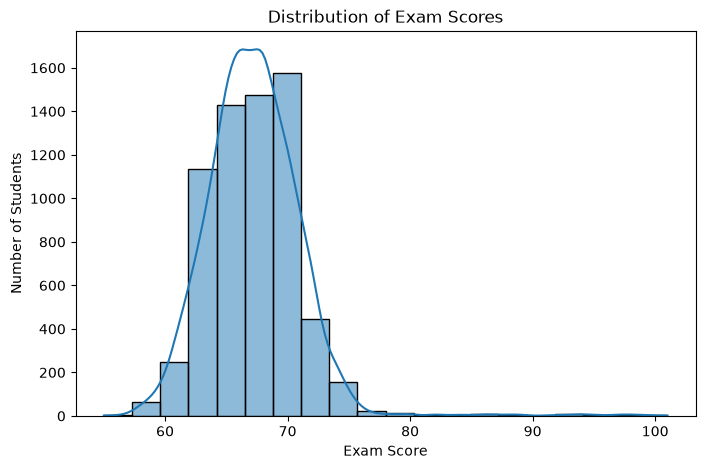

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

### Observation

The distribution of **Exam_Score** is approximately bell-shaped, with most students scoring between **63 and 71 marks**. The highest concentration of students is around **67–69 marks**, indicating that this is the most common performance range.

A slight right-skew is observed due to a small number of students achieving exceptionally high scores (above 80). Overall, the target variable is reasonably distributed and suitable for building a regression model.

## 9. Explore Categorical Features

The categorical features were explored to identify their unique categories before applying encoding. Machine learning algorithms require numerical input, so categorical values must be converted into numerical representations during preprocessing.

In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Parental_Involvement
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Motivation_Level
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Family_Income
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Teacher_Quality
<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

School_Type
<StringArray>
['Public', 'Private']
Length: 2, dtype: str

Peer_Influence
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Learning_Disabilities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Parental_Education_Level
<StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str

Distance_from_Home
<StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str

Gender
<StringArray>
['Male', 

### Observation

The categorical features include both **binary** categories (such as Yes/No and Male/Female) and **ordinal** categories (such as Low/Medium/High).

Since several features have a natural order, manual mapping will be used instead of applying Label Encoding to every column. This preserves the logical relationship between the categories and provides more meaningful numerical representations for the regression model.

In [12]:
mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "No": 0,
    "Yes": 1,
    "Male": 1,
    "Female": 0,
    "Public": 0,
    "Private": 1,
    "Near": 0,
    "Moderate": 1,
    "Far": 2,
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "High School": 0,
    "College": 1,
    "Postgraduate": 2
}

In [13]:
df = df.replace(mapping)

In [14]:
df = df.infer_objects(copy=False)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   int64
 13  Peer_Influence              6607 non-null   int64
 14  Physical_Activity  

### Observation

All categorical features were successfully converted into numerical values using manual mapping. After applying `infer_objects()`, every feature was stored as a numeric data type (`int64`), making the dataset fully compatible with machine learning algorithms.

## 11. Feature Selection

The dataset was divided into **input features (X)** and the **target variable (y)**. The input features will be used to train the regression model, while the target variable (**Exam_Score**) represents the value to be predicted.

In [16]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (6607, 19)
Target Shape : (6607,)


### Observation

The dataset was successfully divided into **19 input features** and **1 target variable**. The input features will be used to train the regression model, while **Exam_Score** serves as the prediction target.

## 12. Train-Test Split

The dataset was divided into training and testing sets using an **80:20 ratio**. The training data is used to train the regression model, while the testing data is used to evaluate how well the model performs on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (5285, 19)
Testing Features  : (1322, 19)
Training Target   : (5285,)
Testing Target    : (1322,)


### Observation

The dataset was successfully split into training and testing sets using an **80:20 ratio**.

- **Training Set:** 5,285 records
- **Testing Set:** 1,322 records

The training data will be used to train the regression model, while the testing data will be used to evaluate its performance on unseen data. This helps measure how well the model generalizes to new student records.

## 13. Feature Scaling

Feature scaling was performed using **StandardScaler** to bring all numerical features to a common scale. The scaler was fitted only on the training data to prevent data leakage and then applied to both the training and testing datasets.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Observation

The input features were standardized using **StandardScaler**. The scaler was fitted only on the training data and then applied to the testing data, ensuring that no information from the test set influenced the training process. This prevents data leakage and creates a reliable machine learning pipeline.

## 14. Train Linear Regression Model

A **Linear Regression** model was trained using the standardized training dataset to learn the relationship between the input features and the target variable (**Exam_Score**).

In [20]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[ 1.76, 2.29, 0.7 ,..., 0.38,-0.31,-0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,67.22
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](19,)","[76.31,75.88,75.46,...,70.52,69.89,69.51]"


## 15. Model Prediction and Evaluation

The trained Linear Regression model was used to predict exam scores for the testing dataset. The model's performance was evaluated using **R² Score**, **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, and **Root Mean Squared Error (RMSE)**.

In [21]:
y_pred = lr_model.predict(X_test_scaled)

In [22]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("R² Score :", round(r2,4))
print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE :", round(rmse,4))

R² Score : 0.7709
MAE : 0.4443
MSE : 3.2379
RMSE : 1.7994


### Observation

The Linear Regression model achieved an **R² Score of 0.7709**, indicating that it explains approximately **77% of the variation** in students' exam scores.

The model produced a **Mean Absolute Error (MAE) of 0.4443**, which means the predicted score differs from the actual score by less than half a mark on average.

Additionally, the **RMSE of 1.7994** indicates that the model's predictions are generally within **2 marks** of the actual exam scores. Overall, the model demonstrates good predictive performance and is suitable for deployment in the Flask application.

In [24]:
results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})

results.head(10)

,Actual Score,Predicted Score
0,65,64.62
1,65,65.29
2,71,71.51
3,64,64.30
4,66,66.42
5,66,66.57
6,72,72.51
7,66,66.37
8,70,70.00
9,70,70.04


## 16. Actual vs Predicted Values

A scatter plot was created to compare the actual exam scores with the predicted exam scores. If the model performs well, most data points should lie close to the diagonal reference line, indicating accurate predictions.

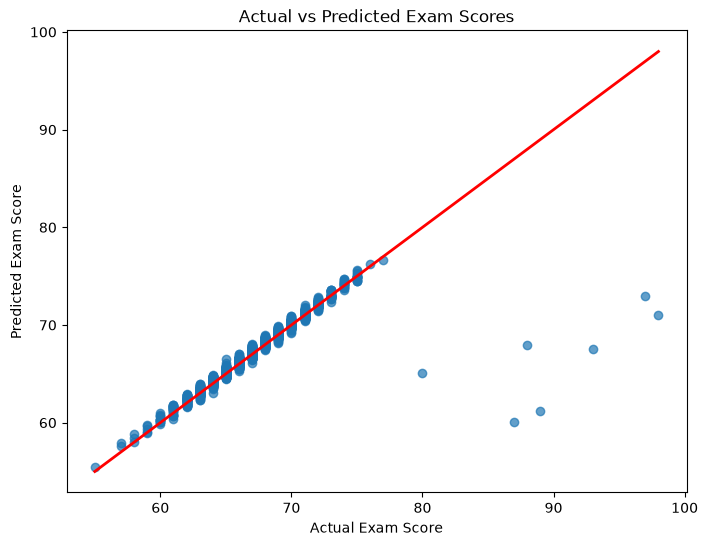

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Exam Scores")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.show()

### Observation

The scatter plot shows that most predicted exam scores are very close to the actual scores, as the majority of the data points lie near the red diagonal reference line. This indicates that the Linear Regression model has learned the relationship between the input features and the target variable effectively.

However, a few students with exceptionally high actual exam scores are predicted lower than their true scores. This suggests that the Linear Regression model performs well for most students but has some difficulty capturing extreme values due to its linear nature.

Overall, the model demonstrates good predictive performance and provides reliable predictions for the majority of student records.

## 17. Save the Trained Model

The trained Linear Regression model and the fitted StandardScaler were saved using **Joblib**. Saving these objects allows the trained model to be reused without retraining and enables seamless integration with the Flask application for real-time predictions.

In [32]:
import joblib

# Save the trained model
joblib.dump(lr_model, "model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
